# Лабораторная работа 6. Классификация изображений на PyTorch

**Вариант 9**

Сравнение SVM и сверточных нейронных сетей на Fashion-MNIST. Реализуются CNN с L2-регуляризацией и Dropout, сравниваются время обучения и точность, строятся две confusion matrix.

## Теоретическая справка

Классификация изображений сопоставляет изображение одному из заранее заданных классов. Fashion-MNIST содержит изображения одежды 28×28 в оттенках серого и 10 классов. SVM строит разделяющую поверхность в пространстве признаков, а CNN автоматически извлекает локальные признаки свёрточными слоями.

Accuracy — доля правильных ответов. Confusion matrix показывает, какие истинные классы модель путает между собой. L2-регуляризация добавляет к функции потерь штраф за большие веса, а Dropout случайно отключает часть нейронов на обучении и уменьшает переобучение.

In [1]:
from pathlib import Path
import gzip
import struct
import time
from urllib.request import urlopen

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}; устройство: {DEVICE}')

PyTorch: 2.14.0; устройство: cpu


## 1. Загрузка Fashion-MNIST без torchvision

Полный набор: train=(60000, 28, 28), test=(10000, 28, 28)


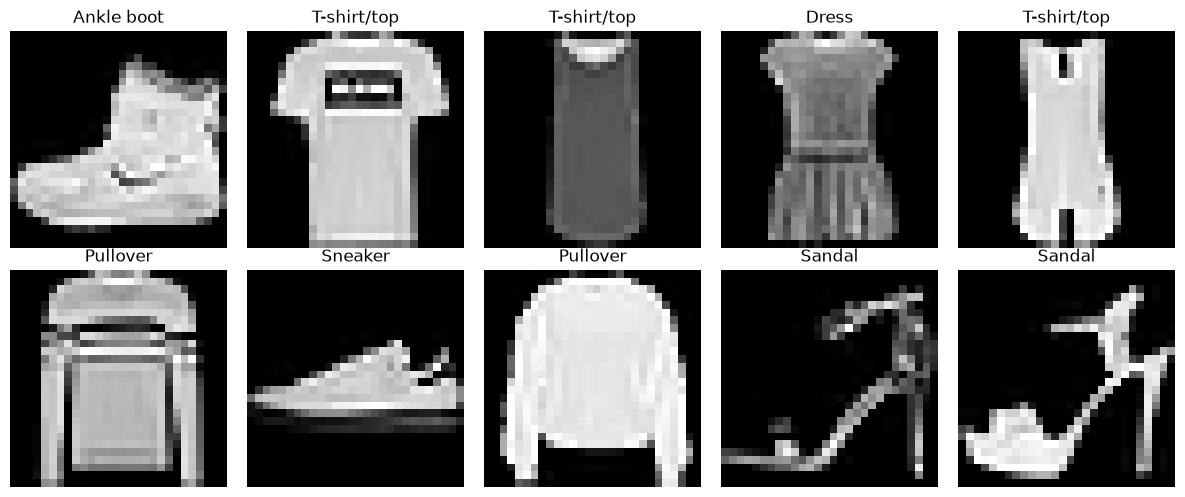

In [2]:
DATA_DIR = Path('fashion_mnist_data')
DATA_DIR.mkdir(exist_ok=True)
BASE_URL = 'https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/'
FILES = {
    'train_images': 'train-images-idx3-ubyte.gz',
    'train_labels': 'train-labels-idx1-ubyte.gz',
    'test_images': 't10k-images-idx3-ubyte.gz',
    'test_labels': 't10k-labels-idx1-ubyte.gz',
}

def download_file(name):
    path = DATA_DIR / name
    if not path.exists():
        try:
            path.write_bytes(urlopen(BASE_URL + name, timeout=300).read())
        except Exception as error:
            raise RuntimeError(f'Не удалось скачать {name}: {error}')
    return path

def read_idx(path):
    with gzip.open(path, 'rb') as stream:
        magic = struct.unpack('>I', stream.read(4))[0]
        ndim = magic & 0xFF
        shape = struct.unpack('>' + 'I' * ndim, stream.read(4 * ndim))
        data = np.frombuffer(stream.read(), dtype=np.uint8)
    return data.reshape(shape)

train_images = read_idx(download_file(FILES['train_images']))
train_labels = read_idx(download_file(FILES['train_labels']))
test_images = read_idx(download_file(FILES['test_images']))
test_labels = read_idx(download_file(FILES['test_labels']))
print(f'Полный набор: train={train_images.shape}, test={test_images.shape}')

# Учебный режим: достаточно большой для сравнения, но воспроизводимый на CPU.
TRAIN_SIZE, TEST_SIZE = 10000, 2000
x_train = train_images[:TRAIN_SIZE].astype(np.float32) / 255.0
y_train = train_labels[:TRAIN_SIZE].astype(np.int64)
x_test = test_images[:TEST_SIZE].astype(np.float32) / 255.0
y_test = test_labels[:TEST_SIZE].astype(np.int64)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for index, axis in enumerate(axes.flat):
    axis.imshow(x_train[index], cmap='gray')
    axis.set_title(class_names[y_train[index]])
    axis.axis('off')
plt.tight_layout()
plt.show()

## 2. SVM на векторизованных изображениях

Для SVM изображение 28×28 разворачивается в вектор из 784 признаков. Используется линейный SVM: это практичный режим для учебного сравнения на CPU.

In [3]:
X_train = x_train.reshape(TRAIN_SIZE, -1)
X_test = x_test.reshape(TEST_SIZE, -1)
svm_model = LinearSVC(C=1.0, dual='auto', max_iter=2000, random_state=SEED)
svm_start = time.perf_counter()
svm_model.fit(X_train, y_train)
svm_time = time.perf_counter() - svm_start
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print(f'SVM: время обучения = {svm_time:.2f} с; accuracy = {svm_accuracy:.4f}')
print(classification_report(y_test, svm_pred, target_names=class_names, zero_division=0))

SVM: время обучения = 5.50 с; accuracy = 0.8190
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.75      0.77       200
     Trouser       0.94      0.95      0.94       203
    Pullover       0.72      0.74      0.73       214
       Dress       0.79      0.77      0.78       190
        Coat       0.73      0.73      0.73       219
      Sandal       0.93      0.91      0.92       195
       Shirt       0.58      0.59      0.58       197
     Sneaker       0.88      0.91      0.89       200
         Bag       0.90      0.91      0.91       194
  Ankle boot       0.95      0.95      0.95       188

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



## 3. CNN на тех же данных

Свёрточный слой извлекает локальные признаки, pooling уменьшает пространственный размер, а полносвязный слой выполняет классификацию. Обе CNN обучаются на одинаковых подвыборках и с одинаковым числом эпох.

In [4]:
def make_loader(images, labels, batch_size=128, shuffle=False):
    tensors = torch.from_numpy(images[:, None, :, :])
    targets = torch.from_numpy(labels)
    return DataLoader(TensorDataset(tensors, targets), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(x_train, y_train, shuffle=True)
test_loader = make_loader(x_test, y_test)

class FashionCNN(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, 10)
        )
    def forward(self, values):
        return self.classifier(self.features(values))

def train_model(model, epochs=2, weight_decay=0.0):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_accuracy': [], 'test_accuracy': []}
    start = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        correct = total = loss_sum = 0.0
        for values, targets in train_loader:
            values, targets = values.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            logits = model(values)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * targets.size(0)
            correct += (logits.argmax(1) == targets).sum().item()
            total += targets.size(0)
        test_acc = evaluate(model)[0]
        history['train_loss'].append(loss_sum / total)
        history['train_accuracy'].append(correct / total)
        history['test_accuracy'].append(test_acc)
        print(f'epoch {epoch + 1}/{epochs}: loss={loss_sum / total:.4f}, train_acc={correct / total:.4f}, test_acc={test_acc:.4f}')
    return model, history, time.perf_counter() - start

@torch.no_grad()
def evaluate(model):
    model.eval()
    predictions, targets_all = [], []
    for values, targets in test_loader:
        logits = model(values.to(DEVICE))
        predictions.extend(logits.argmax(1).cpu().numpy())
        targets_all.extend(targets.numpy())
    predictions, targets_all = np.array(predictions), np.array(targets_all)
    return accuracy_score(targets_all, predictions), targets_all, predictions

baseline_cnn, baseline_history, cnn_time = train_model(FashionCNN(), epochs=2)
cnn_accuracy, cnn_true, cnn_pred = evaluate(baseline_cnn)
print(f'CNN: время обучения = {cnn_time:.2f} с; accuracy = {cnn_accuracy:.4f}')

epoch 1/2: loss=0.9725, train_acc=0.6590, test_acc=0.7140


epoch 2/2: loss=0.5485, train_acc=0.7936, test_acc=0.8255
CNN: время обучения = 4.36 с; accuracy = 0.8255


## 4. L2-регуляризация против Dropout

epoch 1/2: loss=0.9151, train_acc=0.6723, test_acc=0.7705


epoch 2/2: loss=0.5091, train_acc=0.8069, test_acc=0.7840


epoch 1/2: loss=1.0785, train_acc=0.6077, test_acc=0.7735


epoch 2/2: loss=0.6470, train_acc=0.7592, test_acc=0.8080
CNN: время=4.36 с, accuracy=0.8255
CNN + L2: время=4.41 с, accuracy=0.7840
CNN + Dropout: время=4.35 с, accuracy=0.8080


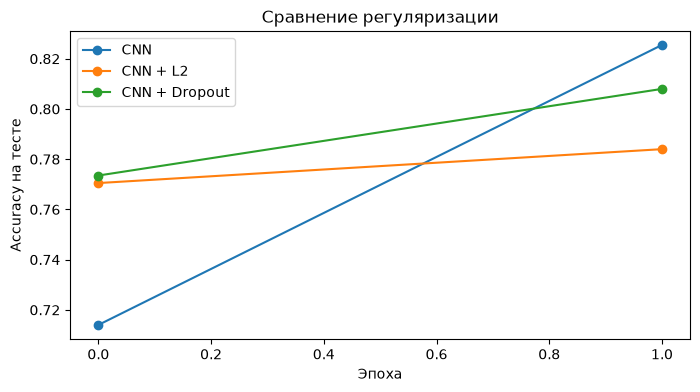

In [5]:
l2_cnn, l2_history, l2_time = train_model(FashionCNN(), epochs=2, weight_decay=1e-4)
l2_accuracy, l2_true, l2_pred = evaluate(l2_cnn)
dropout_cnn, dropout_history, dropout_time = train_model(FashionCNN(dropout=0.5), epochs=2)
dropout_accuracy, dropout_true, dropout_pred = evaluate(dropout_cnn)

comparison = {
    'CNN': (cnn_time, cnn_accuracy),
    'CNN + L2': (l2_time, l2_accuracy),
    'CNN + Dropout': (dropout_time, dropout_accuracy),
}
for name, (elapsed, accuracy) in comparison.items():
    print(f'{name}: время={elapsed:.2f} с, accuracy={accuracy:.4f}')

fig, axis = plt.subplots(figsize=(8, 4))
for name, history in [('CNN', baseline_history), ('CNN + L2', l2_history), ('CNN + Dropout', dropout_history)]:
    axis.plot(history['test_accuracy'], marker='o', label=name)
axis.set_xlabel('Эпоха')
axis.set_ylabel('Accuracy на тесте')
axis.set_title('Сравнение регуляризации')
axis.legend()
plt.show()

## 5. Матрицы ошибок для двух CNN

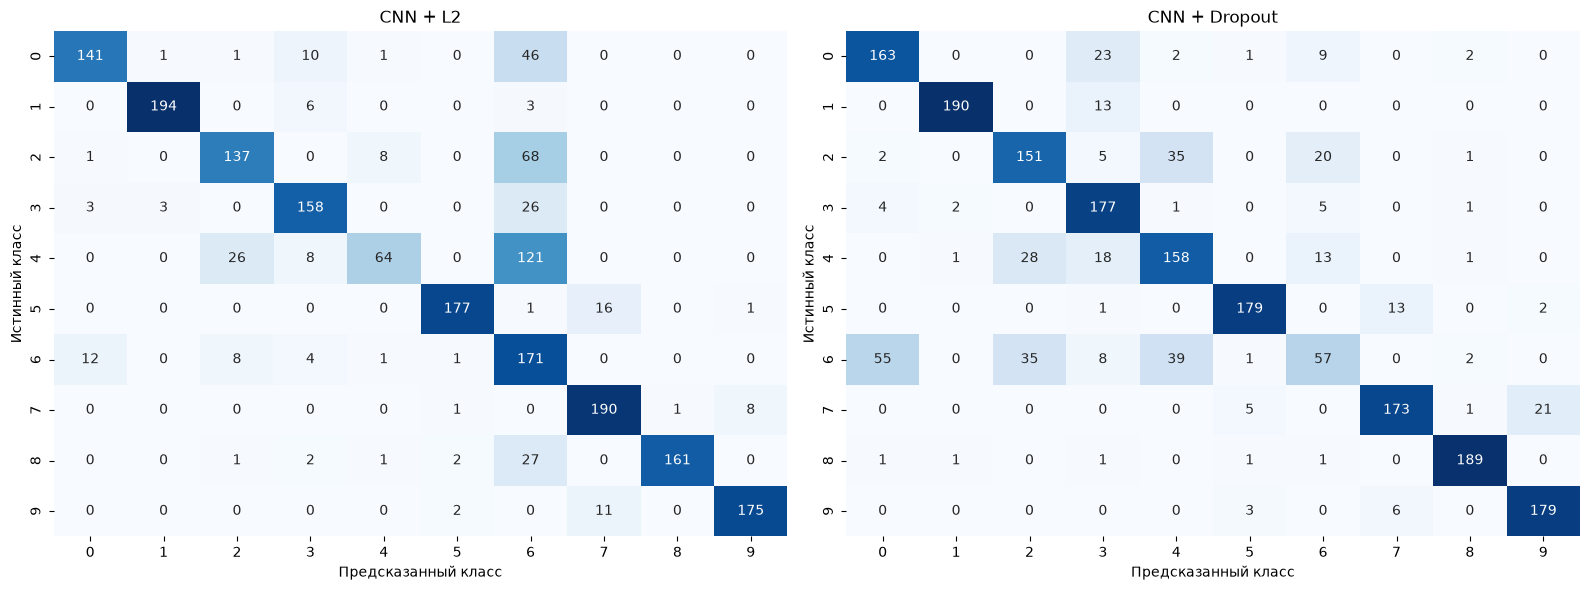

Строки матриц соответствуют классам: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [6]:
cm_l2 = confusion_matrix(l2_true, l2_pred)
cm_dropout = confusion_matrix(dropout_true, dropout_pred)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for axis, matrix, title in zip(axes, [cm_l2, cm_dropout], ['CNN + L2', 'CNN + Dropout']):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(title)
    axis.set_xlabel('Предсказанный класс')
    axis.set_ylabel('Истинный класс')
plt.tight_layout()
plt.show()
print('Строки матриц соответствуют классам:', class_names)

## Вывод

SVM работает с плоскими пиксельными признаками и даёт базовый ориентир по времени и accuracy. CNN использует пространственную структуру изображения и обычно достигает большей точности. L2-регуляризация ограничивает величины весов через `weight_decay`, а Dropout случайно выключает нейроны во время обучения. Confusion matrix показывает, какие виды одежды модель распознаёт уверенно, а какие визуально похожие классы путает.

## Ответы на контрольные вопросы

1. Классификация изображений — отнесение изображения к одному из заранее определённых классов.
2. kNN использует близость объектов, SVM строит разделяющую гиперплоскость, Random Forest объединяет деревья решений.
3. CNN автоматически извлекает локальные признаки, учитывает пространственную структуру и использует меньше параметров, чем полностью связанная сеть для тех же пикселей.
4. Confusion matrix — таблица, где строки являются истинными классами, а столбцы — предсказанными.
5. Кроме Accuracy используют Precision, Recall, F1-score и ROC-AUC; для многоклассовой задачи полезны macro и weighted усреднения.